# Ordinal Regression for activity data

Here we look at regression where the response variable is ordinal and look at the best way of finding good mutations. We start with preprocessed data. Then these are the steps

1. Import data and clean further
1. Look at package Mord for ordinal regression
1. Compare with other multi classification schemes
1. Select one and save data


## Import Dataset and Post Process
Here we import the activity data and do a few post processing steps

1. Remove duplicate sequences 
1. Remove sequences with stops in the middle
1. Assign sequences to exactly one bin (based on where it is most likely)   
   **TODO (if needed)**: We can look at schemes like weighting a sequence into different bins based on read counts


In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import Bio
import Bio.Seq

In [2]:
df = pd.read_pickle("data/azid_activity.pkl")

print("\n>> Response Value Counts")
print(df.response.value_counts())
print(f"\n>> Number of sequences : {len(df)}")
N = len(df.iloc[0].sequence)
print(f"\n>> Length of a sequence : {N}")
print(f"\n>> Number of unique sequences : {len(df.sequence.unique())}")
df.head()


>> Response Value Counts
0    706
1    177
2     54
3     23
Name: response, dtype: int64

>> Number of sequences : 960

>> Length of a sequence : 274

>> Number of unique sequences : 905


,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16268,3
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,9941,3
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,8031,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,5729,3
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,3147,3


In [3]:
# WildType Sequence
WT_DNA = 'ATGCAGCATACCTATCCGGCACAGCTGATGCGTTTTGGCACCGCAGCACGTGCAGAACATATGACCATTGCAGCAGCAATTCATGCACTGGATGCAGATGAAGCAGATGCAATTGTTATGGATATTGTTCCGGATGGTGAACGTGATGCATGGTGGGATGATGAAGGTTTTAGCAGCAGCCCGTTTACCAAAGATGCACATCATGCAGGAGTTGTTGCAACCAGCGTTACCCTGGGTCAGCTGCAGCGTGAACAGGGTGATAAACTGGTTAGCAAAGCAGCAGAATATTTTGGTATTGCCTGCCGTGTTAATGATGGTCTGCGTACCACCCGTTTTGTTCGTCTGTTTAGTGATGCCCTGGATGCCAAACCGCTGACCATTGGTCATGATTATGAAGTTGAATTTCTGCTGGCAACCCGTCGTGTTTATGAACCGTTTGAAGCACCGTTTAACTTTGCACCGCATTGTGGCGATGTTAGCTATGGTCGTGATACCGTTAATTGGCCTCTGAAACATAGCTTTCCGCGTCAGCTGGGTGGTTTTCTGACCATTCAGGGTGCAGATAATGATGCCGGTATGGTTATGTGGGATAATCGTCCGGAAAGCCGTGCAGCGCTGGATGAAATGCATGCAGAATATCGTGAAACCGGTGCAATTGCCGCACTGGAACGTGCAGCCAAAATCATGCTGAAACCGCAGCCTGGCCAGCTGACACTGTTTCAGAGCAAAAATCTGCATGCCATTGAACGTTGTACCAGCACCCGTCGTACCATGGGTCTGTTTCTGATTCATACCGAAGATGGTTGGCGTATGTTTGATTGA'
WT_full = Bio.Seq.Seq(WT_DNA).translate()
WT_full

Seq('MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDGERDAWWDD...FD*', HasStopCodon(ExtendedIUPACProtein(), '*'))

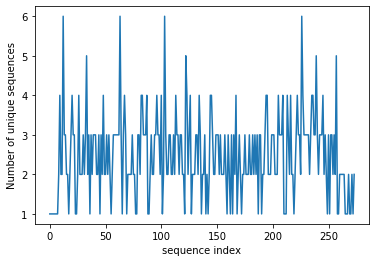

In [4]:
# Number of unique mutations at each index
num_unique = np.array([len(df.sequence.str.get(i).unique()) for i in range(N)])
plt.plot(num_unique)
plt.xlabel("sequence index")
plt.ylabel("Number of unique sequences");

In [5]:
# location of the first stop sequence
df["first_stop"] = df.sequence.str.find("*")
num_stops_in_middle = (df.first_stop != (N-1)).sum()
print(f">> Number of sequences with a stop before the end : {num_stops_in_middle}")

# print out wherever we have a stop in the middle
#df[df.first_stop != (N-1)]

>> Number of sequences with a stop before the end : 33


In [6]:
df_nostop = df[df.first_stop == (len(WT_full) -1)].drop(columns=['first_stop'])
df_nostop.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16268,3
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,9941,3
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,8031,3
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,5729,3
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,3147,3


In [7]:
# Where is WildType in this dataframe
df_nostop[df_nostop.sequence == WT_full]

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16268,3
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,25568,2
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1185,1
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,515,0


In [8]:
# Replace non-unique sequences with their response category with the highest count
df_unique = df_nostop.sort_values('count', ascending=False).groupby('sequence').head(1).reset_index(drop=True)
df_unique.head()

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,25568,2
1,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,16082,2
2,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,12035,2
3,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,9704,2
4,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,4234,2


In [9]:
# Where is WT in this dataframe
# It should be at the top
WT_in_df = df_unique[df_unique.sequence==WT_full]
if WT_in_df.index[0] != 0:
    print(" >> WARNING: WT is not at the top of the dataframe")
WT_in_df

,sequence,count,response
0,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,25568,2


In [10]:
# Drop the Start and STOP Codons
df_unique.sequence = df_unique.sequence.str.slice(1, (len(WT_full)-1))
WT = WT_full[1:-1]
WT_str = str(WT)
N = len(WT_str)

## Ordinal regression

We are using the [mord package](https://github.com/fabianp/mord) to do ordinal regression. The steps in this section are 
1. Create design matrix and response vector
2. Run a cross validated search for the best regularization parameter
3. Save coefficients

In [11]:
from sklearn.preprocessing import OneHotEncoder # to create the design matrix
from sklearn.metrics import mean_absolute_error, make_scorer
from sklearn.model_selection import cross_val_score

import mord
from mord import LogisticAT

In [12]:
y = df_unique.response.to_numpy()
design_cols = df_unique.sequence.apply(lambda x: pd.Series(list(x)))

# one hot encode the design columns to get a design matrix
enc = OneHotEncoder(
    drop=None, # don't drop columns 
    sparse=False ) # setting to False for now

X = enc.fit_transform(design_cols)
print(X.shape)
X

(872, 656)


array([[1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       ...,
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.],
       [1., 1., 1., ..., 1., 0., 1.]])

In [13]:
# Try out model with alpha = 1.0. This will get overwritten in the gridsearch
model = mord.LogisticAT(alpha=1.0)

model.fit(X, y)

# The score is negative of mean absolute error between prediction and response vector
print(f"Model Score with alpha={model.alpha} : {model.score(X, y):.2f}")

Model Score with alpha=1.0 : -0.14


In [14]:
from sklearn.pipeline import Pipeline
from sklearn.feature_selection import VarianceThreshold
from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import accuracy_score

In [15]:
# Create pipeline with mord so that we are removing features that are all one
# Also we are standardizing features by their mean and standard deviation
pipeline = Pipeline([('vt', VarianceThreshold()), 
                     ('scaler', StandardScaler()), 
                     ('model', model)])

alphas = np.logspace(-6, 2, 10) # search space for regularization params
grid_cv = GridSearchCV(estimator=pipeline, param_grid=dict(model__alpha=alphas), 
                       cv=StratifiedKFold(5), n_jobs=5, iid='deprecated')
_ = grid_cv.fit(X, y)

>> Grid Search best params : {'model__alpha': 12.915496650148826}


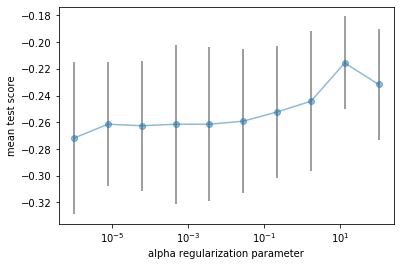

In [16]:
# regularization parameter picked by CV
print(f">> Grid Search best params : {grid_cv.best_params_}")

plt.errorbar(alphas, grid_cv.cv_results_["mean_test_score"],
             grid_cv.cv_results_["std_test_score"], fmt='-o', ecolor="black", alpha=0.5)
plt.xscale('log')
plt.xlabel("alpha regularization parameter")
plt.ylabel("mean test score");

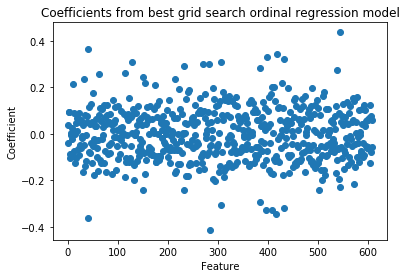

In [17]:
# Now fit the model with the best parameter to the entire dataset
best_model = grid_cv.best_estimator_
best_alpha = best_model.get_params()['model__alpha']

best_model.fit(X, y)
best_coefs = grid_cv.best_estimator_['model'].coef_

plt.plot(best_coefs, 'o')
plt.title("Coefficients from best grid search ordinal regression model")
plt.xlabel("Feature")
plt.ylabel("Coefficient");

In [18]:
# Find feature names after the variance threshold
vt = grid_cv.best_estimator_.named_steps['vt']
feature_names_after_threshold = enc.get_feature_names()[vt.get_support()]

best_results = pd.DataFrame({'feature':feature_names_after_threshold, 'coef':best_coefs})
# extract the Residue index and the AA mutation 
best_results[["idx", "aa_mut"]] = \
    best_results.feature.str.extractall(r"x([0-9]+)_([A-Z])").reset_index(drop=True)
best_results["idx"] = best_results.idx.astype(int)

In [19]:
descending_sort_results = best_results.sort_values('coef', ascending=False)
descending_sort_results.head(10)

,feature,coef,idx,aa_mut
543,x237_Q,0.436565,237,Q
41,x24_T,0.363462,24,T
417,x190_S,0.344590,190,S
397,x180_P,0.328705,180,P
431,x195_D,0.319409,195,D
129,x62_E,0.310071,62,E
306,x136_A,0.306836,136,A
283,x125_I,0.298532,125,I
270,x121_I,0.298522,121,I
232,x106_C,0.291693,106,C


In [20]:
print(descending_sort_results.iloc[0])

def show_design_response(col_num):
    ret =  pd.DataFrame({'aa':design_cols[col_num], 'response':y}).groupby(['aa', 'response']).size()
    ret = ret.to_frame()
    ret["res_idx"] = col_num
    ret.columns = ["count", "res_idx"]
    return ret

show_design_response(descending_sort_results.iloc[0].idx)

feature      x237_Q
coef       0.436565
idx             237
aa_mut            Q
Name: 543, dtype: object


count  res_idx
aa response                
L  0           645      237
   1           157      237
   2            54      237
   3            11      237
Q  3             3      237
V  0             2      237

In [21]:
print(descending_sort_results.iloc[1])
show_design_response(descending_sort_results.iloc[1].idx)

feature       x24_T
coef       0.363462
idx              24
aa_mut            T
Name: 41, dtype: object


count  res_idx
aa response                
A  0           647       24
   1           157       24
   2            54       24
   3            10       24
T  3             4       24

In [22]:
ascending_sort_results = best_results.sort_values('coef', ascending=True)
ascending_sort_results.head(10)

,feature,coef,idx,aa_mut
285,x125_V,-0.413846,125,V
40,x24_A,-0.363462,24,A
416,x190_G,-0.344590,190,G
408,x185_T,-0.329750,185,T
396,x180_L,-0.328705,180,L
432,x195_E,-0.319409,195,E
307,x136_T,-0.306836,136,T
383,x174_H,-0.294050,174,H
502,x225_E,-0.243547,225,E
150,x71_A,-0.242269,71,A


In [23]:
print(ascending_sort_results.iloc[0])
show_design_response(ascending_sort_results.iloc[0].idx)

feature      x125_V
coef      -0.413846
idx             125
aa_mut            V
Name: 285, dtype: object


count  res_idx
aa response                
F  0             6      125
I  0           636      125
   1           157      125
   2            54      125
   3            14      125
T  0             2      125
V  0             3      125

In [24]:
print(ascending_sort_results.iloc[1])
show_design_response(ascending_sort_results.iloc[1].idx)

feature       x24_A
coef      -0.363462
idx              24
aa_mut            A
Name: 40, dtype: object


count  res_idx
aa response                
A  0           647       24
   1           157       24
   2            54       24
   3            10       24
T  3             4       24

## Model comparison

Here we compare various models against ordinal regression. Among them, ridge regression, logistic regression
Loosely based on [someone's blog post](https://rikunert.com/ordinal_rating)

In [25]:
from sklearn.linear_model import Ridge, LinearRegression, LogisticRegression


# instantiate models
model_linear = Ridge()
model_1vR = LogisticRegression(multi_class='ovr', fit_intercept=False, 
    class_weight=None)
model_multi = LogisticRegression(multi_class='multinomial', fit_intercept=False,
    solver='lbfgs',
    class_weight=None, C = 0.001 )
model_ordinal = LogisticAT(alpha=0)
model_ordinal_best = LogisticAT(alpha=best_alpha)
folds = StratifiedKFold(5)
MAE = make_scorer(mean_absolute_error)


import sklearn.base
class PredictZero(sklearn.base.BaseEstimator):
    """This class predicts zero for every input"""
    def __init__(self):
        self.alpha = 0
    
    def fit(self, *args, **kwargs):
        return self
    
    def predict(self, X):
        return np.zeros(X.shape[0], dtype=np.int)
    
model_zero = PredictZero()

In [26]:
model_dict = {"zero":model_zero, "ridge":model_linear, "lr1vR":model_1vR, "multinomial":model_multi,
             "ordinal":model_ordinal, "ordinal_best":model_ordinal_best}

In [27]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)


x = [cross_val_score(m, X, y, cv=folds, scoring=MAE) for k, m in model_dict.items()]
mae_test_results = pd.DataFrame(x, index=model_dict.keys())
mae_test_results

,0,1,2,3,4
zero,0.357955,0.357955,0.356322,0.356322,0.331395
ridge,0.354464,0.332994,0.319232,0.377963,0.388832
lr1vR,0.272727,0.232955,0.270115,0.321839,0.279070
multinomial,0.357955,0.357955,0.356322,0.356322,0.331395
ordinal,0.215909,0.244318,0.218391,0.419540,0.383721
ordinal_best,0.340909,0.352273,0.350575,0.362069,0.319767


In [28]:
# Average Mean Absolute Errors
mae_test_results.mean(axis=1).to_frame().T

,zero,ridge,lr1vR,multinomial,ordinal,ordinal_best
0,0.35199,0.354697,0.275341,0.35199,0.296376,0.345119


In [29]:
def acc_fun(target_true, target_fit):
    target_fit = np.round(target_fit)
    target_fit.astype('int')
    return accuracy_score(target_true, target_fit)

acc = make_scorer(acc_fun)

In [30]:
x = [cross_val_score(m, X, y, cv=folds, scoring=acc) for k, m in model_dict.items()]
acc_test_results = pd.DataFrame(x, index=model_dict.keys())
acc_test_results

,0,1,2,3,4
zero,0.738636,0.738636,0.741379,0.741379,0.750000
ridge,0.784091,0.801136,0.810345,0.724138,0.750000
lr1vR,0.801136,0.835227,0.804598,0.764368,0.784884
multinomial,0.738636,0.738636,0.741379,0.741379,0.750000
ordinal,0.840909,0.784091,0.804598,0.689655,0.726744
ordinal_best,0.750000,0.744318,0.741379,0.735632,0.755814


In [31]:
acc_test_results.mean(axis=1).to_frame().T

,zero,ridge,lr1vR,multinomial,ordinal,ordinal_best
0,0.742006,0.773942,0.798043,0.742006,0.769199,0.745429


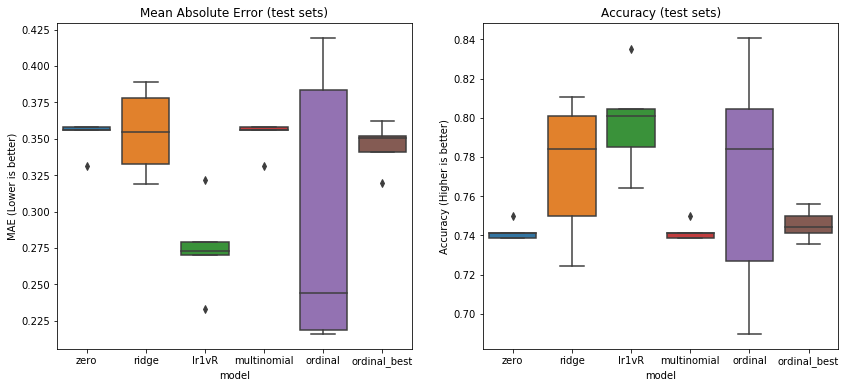

In [32]:
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(14, 6))
ax = axs[0]
sns.boxplot("variable", "value", data=pd.melt(mae_test_results.T), ax=ax)
ax.set(xlabel="model", ylabel="MAE (Lower is better)", title="Mean Absolute Error (test sets)")

ax = axs[1]
sns.boxplot("variable", "value", data=pd.melt(acc_test_results.T), ax=ax)
ax.set(xlabel="model", ylabel="Accuracy (Higher is better)", title="Accuracy (test sets)");

### Picking the best 1vR Classifier

In [33]:
model_1vR = LogisticRegression(multi_class='ovr', fit_intercept=False,
    class_weight='balanced', penalty='l2', C=1.)
model_1vR.fit(X, y)

LogisticRegression(C=1.0, class_weight='balanced', dual=False,
                   fit_intercept=False, intercept_scaling=1, l1_ratio=None,
                   max_iter=100, multi_class='ovr', n_jobs=None, penalty='l2',
                   random_state=None, solver='warn', tol=0.0001, verbose=0,
                   warm_start=False)

In [34]:
pipeline_1vR = Pipeline([('vt', VarianceThreshold()), 
                     ('scaler', StandardScaler()), 
                     ('model', model_1vR)])

Cs = alphas # search space for regularization params
grid_cv = GridSearchCV(estimator=pipeline_1vR, param_grid=dict(model__C=Cs), 
                       cv=StratifiedKFold(5), n_jobs=5, iid='deprecated')
_ = grid_cv.fit(X, y)

In [35]:
best_1vR = grid_cv.best_estimator_
best_C = best_1vR.get_params()["model__C"]
best_C

0.21544346900318823

In [36]:
AAs = 'ACDEFGHIKLMNPQRSTVWY'

def mut_wt(idx, aa):
    mut = WT_str[:idx] + aa + WT_str[(idx+1):]
    return mut

# Create a single mutant for each wildType
seqs = pd.Series([mut_wt(row['idx'], row['aa_mut']) for idx, row in best_results.iterrows()])
mut_cols = seqs.apply(lambda x: pd.Series(list(x)))
mut_one_hot = enc.transform(mut_cols)

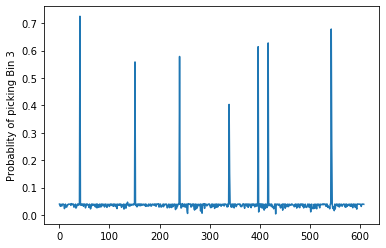

In [37]:
probs = model_1vR.predict_proba(mut_one_hot)
plt.plot(probs[:,3])
plt.ylabel("Probablity of picking Bin 3");

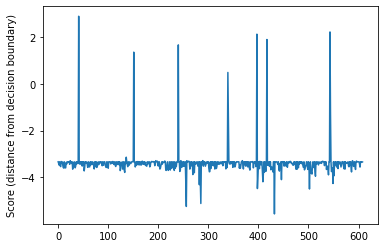

In [38]:
score = model_1vR.decision_function(mut_one_hot)
plt.plot(score[:, 3])
plt.ylabel("Score (distance from decision boundary)")
pass

In [39]:
feature_names_after_threshold[score[:, 3] > 0]

array(['x24_T', 'x71_V', 'x109_C', 'x150_L', 'x180_P', 'x190_S', 'x237_Q'],
      dtype=object)

In [40]:
[(i, show_design_response(i)) for i in (150, 24, 109, 71, 190, 180, 195)]

[(150,              count  res_idx
  aa response                
  F  0           643      150
     1           150      150
     2            54      150
     3            13      150
  L  0             3      150
     1             6      150
     3             1      150
  S  0             1      150
     1             1      150), (24,              count  res_idx
  aa response                
  A  0           647       24
     1           157       24
     2            54       24
     3            10       24
  T  3             4       24), (109,              count  res_idx
  aa response                
  C  3             1      109
  R  0           647      109
     1           157      109
     2            54      109
     3            13      109), (71,              count  res_idx
  aa response                
  A  0           645       71
     1           157       71
     2            54       71
     3            13       71
  V  0             2       71
     3             

### Correlation of features with Bin 3

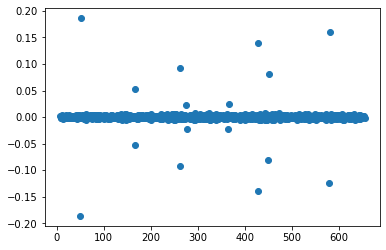

In [41]:
y3 = (y == 3).astype(np.int)
Xt = X.transpose()
X_demean = Xt - Xt.mean(axis=1, keepdims=True)
y_demean = y3 - y.mean(axis=0, keepdims=True)

with np.errstate(divide='ignore',invalid='ignore'):
    corrs = (X_demean @ y_demean) / \
                      (np.linalg.norm(X_demean, axis=1) * np.sqrt(np.dot(y_demean, y_demean)))

plt.plot(corrs, 'o')
pass

In [42]:
with np.errstate(invalid='ignore'):
    print(">> Features with Correlation above threshold")
    print(enc.get_feature_names()[np.argwhere(corrs > 0.01)])
    print()
    print(">> Features with Correlation below -threshold")
    print(enc.get_feature_names()[np.argwhere(corrs < - 0.01)])

>> Features with Correlation above threshold
[['x24_T']
 ['x71_V']
 ['x109_C']
 ['x114_F']
 ['x150_L']
 ['x180_P']
 ['x190_S']
 ['x237_Q']]

>> Features with Correlation below -threshold
[['x24_A']
 ['x71_A']
 ['x109_R']
 ['x114_L']
 ['x150_F']
 ['x180_L']
 ['x190_G']
 ['x237_L']]


In [43]:
[(i, show_design_response(i)) for i in (237, 24, 109, 71, 190, 180, 195)]

[(237,              count  res_idx
  aa response                
  L  0           645      237
     1           157      237
     2            54      237
     3            11      237
  Q  3             3      237
  V  0             2      237), (24,              count  res_idx
  aa response                
  A  0           647       24
     1           157       24
     2            54       24
     3            10       24
  T  3             4       24), (109,              count  res_idx
  aa response                
  C  3             1      109
  R  0           647      109
     1           157      109
     2            54      109
     3            13      109), (71,              count  res_idx
  aa response                
  A  0           645       71
     1           157       71
     2            54       71
     3            13       71
  V  0             2       71
     3             1       71), (190,              count  res_idx
  aa response                
  G  0       

In [44]:
descending_sort_results.head()

,feature,coef,idx,aa_mut
543,x237_Q,0.436565,237,Q
41,x24_T,0.363462,24,T
417,x190_S,0.344590,190,S
397,x180_P,0.328705,180,P
431,x195_D,0.319409,195,D
